# Project Milestone 3
* Data Preparation: DSC 540-T302 
* Mallory Young
* Student #21356619

In [1]:
#importing libraries I might need for this data transformation and/or cleansing
import pandas as pd
import numpy as np

In [2]:
#Assigning the wikipedia website url to 'date_url'
data_url = 'https://en.wikipedia.org/wiki/List_of_Academy_Award%E2%80%93winning_films'

#using pd.read_html to extract tables from the URL and create a list of DataFrame objects
#there is only 1 table, so we use [0]
FilmNom_df = pd.read_html(data_url)[0]
#displaying the table
FilmNom_df

,Film,Year,Awards,Nominations
0,Oppenheimer,2023,7,13
1,Poor Things,2023,4,11
2,The Zone of Interest,2023,2,5
3,American Fiction,2023,1,5
4,Anatomy of a Fall,2023,1,5
...,...,...,...,...
1368,The Yankee Doodle Mouse,1943,1,1
1369,The Yearling,1946,2,7
1370,"Yesterday, Today and Tomorrow (Ieri, oggi, dom...",1964,1,1
1371,You Can't Take It with You,1938,2,7


In [3]:
#printing the data types for each column to refrence when editing the data
FilmNom_df.dtypes

Film           object
Year           object
Awards         object
Nominations    object
dtype: object

## Step 1: Finding Missing Values
This data is from Wikipedia, which some people might argue is not the most reliable source of information. This is because anyone can edit the material on a Wikipedia page at any time, and it's not safe to assume that information has been checked before publication. Therefore, in this case we want to make sure that the dataset is complete and address any possible missing values. 

In general, it is important to determine if a dataset contains missing values for the following reasons: 
* **Data integrity:** It allows me to ensure the integrity of the chosen dataset and to understand the extent of missing data so that I can take the appropriate actions to address it.
* **Data Analysis:** Missing values can impact the accuracy and reliability of future data analysis.
* **Decision Making:** Incomplete data can lead to biased or inaccurate decision-making. By identifying missing values, I am able to make better decisions based on complete and reliable information.

In [4]:
#using the isnull() function to identify missing values
missing_values = FilmNom_df.isnull()
#using .sum() to count the total number of missing values in each column
missing_counts = missing_values.sum()
#displaying the total number of missing values in each column
print(missing_counts)
#Observation: There are no missing values from this dataset

Film           0
Year           0
Awards         0
Nominations    0
dtype: int64


## Step 2: Finding Duplicates
&emsp; The first observation I made about this DataFrame is that the Wikipedia page graph has the Best Picture winning films for each year highlighted and the film title is in bold font. This did not transfer to the DataFrame, therefore the data on Best Picture winning films for each year is missing and will need to be represented in the DataFrame. We will fix this issue in **Step 3**, but first we need to look at film title duplicates...


&emsp; Having duplicates of the same movie might make it difficult to analyze this data later on. First we will find the movies that have duplicates in the "Film" column. Then we will need to investigate whether these duplicates have won the Best Picture Academy Award. We want to make sure we are assigning the correct winning film based on the year it won Best Picture, and not a duplicate film that was nominated a different year. Below is the full list of films that have won the Academy Award for Best Picture. We will compare these film titles with the list of duplicate film titles. 


&emsp; '12 Years a Slave', 'All About Eve', 'All Quiet on the Western Front', 'All the King's Men', 'Amadeus', 'American Beauty', 'An American in Paris', 'Annie Hall', 'The Apartment', 'Argo', 'Around the World in 80 Days', 'The Artist', 'A Beautiful Mind', Ben-Hur', 'The Best Years of Our Lives', 'Birdman', 'Braveheart', 'The Bridge on the River Kwai', 'The Broadway Melody', 'Casablanca', 'Cavalcade', 'Chariots of Fire', 'Chicago', 'Cimarron', 'CODA', 'Crash', 'Dances with Wolves', 'The Deer Hunter', 'The Departed', 'Driving Miss Daisy', 'Everything Everywhere All at Once', 'Forrest Gump', 'The French Connection', 'From Here to Eternity', 'Gandhi', 'Gentleman's Agreement', 'Gigi', 'Gladiator', 'The Godfather', 'The Godfather Part II', 'Going My Way', 'Gone with the Wind', 'Grand Hotel', 'The Great Ziegfeld', 'The Greatest Show on Earth', 'Green Book', 'Hamlet', 'How Green Was My Valley', 'The Hurt Locker', 'In the Heat of the Night', 'It Happened One Night', 'The King's Speech', 'Kramer vs. Kramer', 'The Last Emperor', 'Lawrence of Arabia', 'The Life of Emile Zola', 'The Lord of the Rings: The Return of the King', 'The Lost Weekend', 'A Man for All Seasons', 'Marty', 'Midnight Cowboy', 'Million Dollar Baby', 'Moonlight',  'Mrs. Miniver', 'Mutiny on the Bounty', 'My Fair Lady', 'No Country for Old Men', 'Nomadland', 'Oliver!', 'On the Waterfront', 'One Flew Over the Cuckoo's Nest','Oppenheimer', 'Ordinary People', 'Out of Africa', 'Parasite', 'Patton', 'Platoon', 'Rain Man', 'Rebecca', 'Rocky', 'Schindler's List', 'Shakespeare in Love', 'The Shape of Water', 'The Silence of the Lambs', 'Slumdog Millionaire', 'The Sound of Music', 'Spotlight', 'The Sting', 'Terms of Endearment', 'The English Patient', 'Titanic', 'Tom Jones', 'Unforgiven', 'West Side Story',  'Wings',  'You Can't Take It with You'

In [5]:
#creating an array of unique film titles that are duplicated in the DataFrame
#.duplicated() method with the subset='Film' parameter checks for duplicate values in the "Film" column
#the keep=False parameter marks all instances of the duplicated film titles as True
duplicate_titles = FilmNom_df[FilmNom_df.duplicated(subset='Film', keep=False)]['Film'].unique()
#printing the array of duplicated film titles
print(duplicate_titles)

['All Quiet on the Western Front' 'West Side Story' 'Little Women'
 'A Star Is Born' 'The Great Gatsby' 'Up' 'King Kong'
 'The Old Man and the Sea' 'Titanic' 'Cyrano de Bergerac' 'Henry V'
 'Cleopatra']


In [6]:
#calculating the total number of duplicated film titles using .sum()
duplicate_count = FilmNom_df.duplicated(subset='Film').sum()
print("The number of duplicated rows based on the 'Film' column is:", duplicate_count)
#Observation: There are 12 listed movie titles, but 14 duplicated rows, therefore two movie titles must have 3 occurances

The number of duplicated rows based on the 'Film' column is: 14


In [7]:
#displaying each of the duplicated rows for further investigation...
#.isin() checks for the presence of each film title in the array of duplicate_titles 
#the result is a boolean mask that selects the rows where the condition is True
duplicate_rows = FilmNom_df[FilmNom_df['Film'].isin(duplicate_titles)]
#displaying the full row for the duplicated film titles
duplicate_rows

,Film,Year,Awards,Nominations
14,All Quiet on the Western Front,2022,4,9
36,West Side Story,2021,1,7
60,Little Women,2019,1,6
77,A Star Is Born,2018,1,8
154,The Great Gatsby,2013,2,2
208,Up,2009,2,5
268,King Kong,2005,3,4
361,The Old Man and the Sea,1999,1,1
378,Titanic,1997,11,14
483,Cyrano de Bergerac,1990,1,5


#### Observations: 
The following movies have a duplicate film title in the DataFrame AND won the Academy Award for Best Picture. 
* All Quiet on the Western Front (Award: 1929/30)
* West Side Story (Award: 1961)
* Titanic (Award: 1997)

We will take this information into consideration when addressing the missing data for the Best Picture winning film for each year. 

## Step 3: Creating a New Column with the Missing Values
The screenshot below shows the format of the table on the Wikipedia page with the winning films highlighted and in bold text. To address this  missing data from the DataFrame, we will add a new column with boolean values "True" and "False". Then, we will change all of the values for the film titles that won the Academy Award that year to True. However, we will need to omit the duplicate film titles and edit those separately. This is to ensure that we correctly assign the win (True) to the title for the specific year the film won the award.  
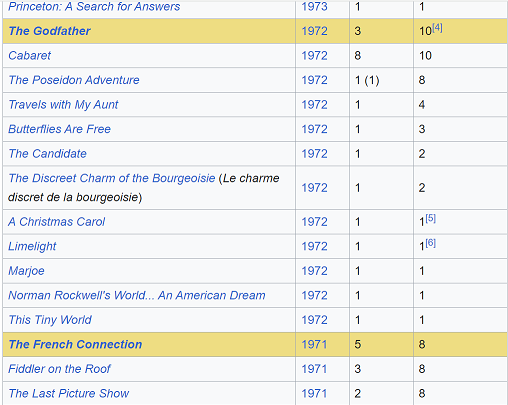

In [8]:
#creating a new "Best Picture Winner" column and setting all values to False
FilmNom_df['Best Picture Winner'] = False

In [9]:
#setting the data type of the "Best Picture Winner" column to bool
FilmNom_df['Best Picture Winner'] = FilmNom_df['Best Picture Winner'].astype(bool)

In [10]:
#confirming the column is type:bool
FilmNom_df['Best Picture Winner'].dtypes

dtype('bool')

In [11]:
#confirming the values in the column are False
FilmNom_df.head()

,Film,Year,Awards,Nominations,Best Picture Winner
0,Oppenheimer,2023,7,13,False
1,Poor Things,2023,4,11,False
2,The Zone of Interest,2023,2,5,False
3,American Fiction,2023,1,5,False
4,Anatomy of a Fall,2023,1,5,False


In [12]:
#the list of Best Picture winning film titles (minus the 3 duplicate film titles)
winning_titles = ['12 Years a Slave', 'All About Eve', 'All the King\'s Men', 'Amadeus', 'American Beauty', 
                   'An American in Paris', 'Annie Hall', 'The Apartment', 'Argo', 'Around the World in 80 Days', 'The Artist', 'A Beautiful Mind',
                   'Ben-Hur', 'The Best Years of Our Lives', 'Birdman', 'Braveheart', 'The Bridge on the River Kwai', 'The Broadway Melody', 
                   'Casablanca', 'Cavalcade', 'Chariots of Fire', 'Chicago', 'Cimarron', 'CODA', 'Crash', 'Dances with Wolves', 'The Deer Hunter', 
                   'The Departed', 'Driving Miss Daisy', 'Everything Everywhere All at Once', 'Forrest Gump', 'The French Connection', 
                   'From Here to Eternity', 'Gandhi', 'Gentleman\'s Agreement', 'Gigi', 'Gladiator', 'The Godfather', 'The Godfather Part II', 
                   'Going My Way', 'Gone with the Wind', 'Grand Hotel', 'The Great Ziegfeld', 'The Greatest Show on Earth', 'Green Book', 'Hamlet', 
                   'How Green Was My Valley', 'The Hurt Locker', 'In the Heat of the Night', 'It Happened One Night', 'The King\'s Speech', 'Kramer vs. Kramer', 'The Last Emperor', 
                  'Lawrence of Arabia', 'The Life of Emile Zola', 'The Lord of the Rings: The Return of the King', 'The Lost Weekend', 
                  'A Man for All Seasons', 'Marty', 'Midnight Cowboy', 'Million Dollar Baby', 'Moonlight',  'Mrs. Miniver', 'Mutiny on the Bounty', 
                  'My Fair Lady', 'No Country for Old Men', 'Nomadland', 'Oliver!', 'On the Waterfront', 'One Flew Over the Cuckoo\'s Nest',
                  'Oppenheimer', 'Ordinary People', 'Out of Africa', 'Parasite', 'Patton', 'Platoon', 'Rain Man', 'Rebecca', 'Rocky', 
                  'Schindler\'s List', 'Shakespeare in Love', 'The Shape of Water', 'The Silence of the Lambs', 'Slumdog Millionaire', 
                  'The Sound of Music', 'Spotlight', 'The Sting', 'Terms of Endearment', 'The English Patient', 'Tom Jones', 'Unforgiven', 
                  'Wings',  'You Can\'t Take It with You']

In [13]:
#isin() checks if the values in the 'Film' column of the DataFrame are present in the list winning_titles
#.loc assigns the string 'True' to the 'Best Picture Winner' column for the rows where the winning_titles are present
FilmNom_df.loc[FilmNom_df['Film'].isin(winning_titles), 'Best Picture Winner'] = 'True'

C:\Users\freck\AppData\Local\Temp\ipykernel_14472\3868180731.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  FilmNom_df.loc[FilmNom_df['Film'].isin(winning_titles), 'Best Picture Winner'] = 'True'


In [14]:
#printing the first 5 rows of the dataframe with the Best Picture winning films marked as "True". 
FilmNom_df.head()
#Observation: It has worked because we see the winning film "Oppenheimer" was changed to True

,Film,Year,Awards,Nominations,Best Picture Winner
0,Oppenheimer,2023,7,13,True
1,Poor Things,2023,4,11,False
2,The Zone of Interest,2023,2,5,False
3,American Fiction,2023,1,5,False
4,Anatomy of a Fall,2023,1,5,False


**As a reminder, the 3 film duplicate film titles omitted from the changes above were:**
* All Quiet on the Western Front (Award: 1929/30) - 2nd occurance 
* West Side Story (Award: 1961) - 2nd occurance
* Titanic (Award: 1997) - 1st occurance


The Titanic title that won the Academy Award for Best Picture in 1997 is the first occurance in the DataFrame. The code will need to identify index [0] in order to change only the first occurance of "Titanic". 


The other two films are the second occurance of the film title in the DataFrame, and therefore we must tell the code to skip the first occurance and change the second occurance of the title by using index [1]. 

In [15]:
#filtering the DataFrame to find the index of the first occurrence of the film 'Titanic'
#assigning the string 'True' to the 'Best Picture Winner' column at the specified index
winning_title_titanic = FilmNom_df[FilmNom_df['Film'] == 'Titanic'].index[0]
FilmNom_df.at[winning_title_titanic, 'Best Picture Winner'] = 'True'

In [16]:
#filtering the DataFrame to find the index of the second occurrence of the film 'All Quiet on the Western Front'
#assigning the string 'True' to the 'Best Picture Winner' column at the specified index
winning_title_AQWF = FilmNom_df[FilmNom_df['Film'] == 'All Quiet on the Western Front'].index[1]
FilmNom_df.at[winning_title_AQWF, 'Best Picture Winner'] = 'True'

In [17]:
#filtering the DataFrame to find the index of the second occurrence of the film 'West Side Story'
#assigning the string 'True' to the 'Best Picture Winner' column at the specified index
winning_title_WSS = FilmNom_df[FilmNom_df['Film'] == 'West Side Story'].index[1]
FilmNom_df.at[winning_title_WSS, 'Best Picture Winner'] = 'True'

In [18]:
#printing the duplicate rows again to make sure the film titles were changed to "True" are at the correct occurances. 
duplicate_rows = FilmNom_df[FilmNom_df['Film'].isin(duplicate_titles)]
duplicate_rows

,Film,Year,Awards,Nominations,Best Picture Winner
14,All Quiet on the Western Front,2022,4,9,False
36,West Side Story,2021,1,7,False
60,Little Women,2019,1,6,False
77,A Star Is Born,2018,1,8,False
154,The Great Gatsby,2013,2,2,False
208,Up,2009,2,5,False
268,King Kong,2005,3,4,False
361,The Old Man and the Sea,1999,1,1,False
378,Titanic,1997,11,14,True
483,Cyrano de Bergerac,1990,1,5,False


## Step 4: Fix Inconsistent Data in the 'Year' Column
There are multiple films who have dual year listed such as 'All Quiet on the Western Front' Year: 1929/30, "Little Women" Year: 1932/33, as well as all of the 2020 award year entries are Year: 2020/21 as seen below.  These inconsistencies in the year column may cause issues when analyzing this data later on. There is clearly data showing the 2021 award season, so the films that won in 2020 don't need to be classified as 2021 as well. Therefore, we can remove the second part of the date for the data that contains more than one year in the 'Year' column. 

In [19]:
#displayig the 2020 and 2021 year entries to show the dual year data for '2020/21'
dual_year = FilmNom_df[FilmNom_df['Year'].isin(['2020/21', '2021'])]
dual_year

,Film,Year,Awards,Nominations,Best Picture Winner
26,CODA,2021,3,3,True
27,Dune,2021,6,10,False
28,The Eyes of Tammy Faye,2021,2,2,False
29,No Time to Die,2021,1,3,False
30,The Windshield Wiper,2021,1,1,False
31,The Long Goodbye,2021,1,1,False
32,The Queen of Basketball,2021,1,1,False
33,Summer of Soul,2021,1,1,False
34,Drive My Car,2021,1,4,False
35,Encanto,2021,1,3,False


In [20]:
#By executing this code, the 'Year' column entries in the format "0000/00" will be modified to "0000"
FilmNom_df['Year'] = FilmNom_df['Year'].str.replace(r'/\d{2}', '', regex=True)

In [21]:
#displaying the 2020 and 1929 years to show that the 'Year" column formatting has been changed
year_changed = FilmNom_df[FilmNom_df['Year'].isin(['2020', '1929'])]
year_changed

,Film,Year,Awards,Nominations,Best Picture Winner
41,Nomadland,2020,3,6,True
42,The Father,2020,2,6,False
43,Judas and the Black Messiah,2020,2,6,False
44,Minari,2020,1,6,False
45,Mank,2020,2,10,False
46,Sound of Metal,2020,2,6,False
47,Ma Rainey's Black Bottom,2020,2,5,False
48,Promising Young Woman,2020,1,5,False
49,Tenet,2020,1,2,False
50,Soul,2020,2,3,False


## Step 5: Fix Inconsistent Data/Format Data into a More Readable Format
In the 'Awards' column, some films have more than one value for the number of awards won. For example, at index #680 King Kong 1976 has the value "0(1)". After further research into the Wikipedia information, it was determined that the extra value represents Special Achievement awards. So, for our King Kong example, the movie was nominated for 2 Academy Awards, but won 0. It did however recieve 1 Special Achievement award. We are not nescessarily interested in Special Achievement awards for this dataset. Therefore, in order to make this data more consistent, we can drop the values for the Special Achievement awards, keeping only the Academy Awards won by the film. 

In [22]:
#There is a space character separating the first value that we want to keep and the second value in () we want to drop
#str[0] selects the first part of the split, effectively dropping everything after the space
FilmNom_df['Awards'] = FilmNom_df['Awards'].str.split().str[0]

In [23]:
#using .iloc to select rows at a specific index
specific_rows = FilmNom_df.iloc[[680, 1032, 1263]]
#displaying three of the rows that originally had more than one value i the "Awards" column
specific_rows

,Film,Year,Awards,Nominations,Best Picture Winner
680,King Kong,1976,0,2,False
1032,Henry V,1946,0,4,False
1263,A Star Is Born,1937,1,7,False


## Step 6: Creating a Hierarchical Index based on "Year"
The Academy Award film data's "Year" column would be useful as a hierarchical index for grouping and indexing films that were nominated and won awards for each Academy Award season (year). Creating a hierarchical index based on the "Year" column can be useful to this data in the following ways: 
* **Organizing Time-Based Data:** By using the "Year" column as the first level of the hierarchical index, it allows us me to organize the data based on the year of the Academy Awards. This is important for easy retrieval and analysis of award nominations and winners across different years.
* **Facilitating Time-Series Analysis:** Hierarchical indexing based on the "Year" column enables efficient time-series analysis later on. This index can allow someone to easily perform operations such as time-based aggregation, trend analysis, and comparisons across different years.
* **Grouping and Aggregation:** Hierarchical indexing allows for grouping and aggregation operations based on the "Year" level. This can be especially useful for summarizing award nominations and wins over time, identifying trends, and understanding the overall distribution of awards across different years.
* **Multi-Level Slicing and Selection:** With hierarchical indexing, I can perform multi-level slicing and selection, enabling you to focus on specific years or ranges of years for in-depth analysis and comparison.
* **Enhanced Data Retrieval:** The hierarchical index based on the "Year" column provides a structured way to retrieve and access data, making it easier to navigate and work with the Academy Award data.

In [24]:
#set_index sets the "Object Name" column as the index of the DataFrame, creating a hierarchical index
#inplace=True directly modifies the original DataFrame without the need for reassignment
FilmNom_df.set_index("Year", inplace=True)

In [25]:
#displaying the DataFrame with the new hierarchial index
FilmNom_df.head(20)

,Film,Awards,Nominations,Best Picture Winner
Year,,,,
2023,Oppenheimer,7,13,True
2023,Poor Things,4,11,False
2023,The Zone of Interest,2,5,False
2023,American Fiction,1,5,False
2023,Anatomy of a Fall,1,5,False
2023,Barbie,1,8,False
2023,The Boy and the Heron,1,1,False
2023,Godzilla Minus One,1,1,False
2023,The Holdovers,1,5,False


In [26]:
#If I was interested in a particular awards season, I could use the hierarchial index to easily retrieve just that data
#Using the .loc and the hierarchial index year of 2019 to view all of the films nominated that Awards season
FilmNom_df.loc["2019"]

,Film,Awards,Nominations,Best Picture Winner
Year,,,,
2019,Parasite,4,6,True
2019,Ford v Ferrari,2,4,False
2019,Learning to Skateboard in a Warzone (If You're...,1,1,False
2019,The Neighbors' Window,1,1,False
2019,Little Women,1,6,False
2019,Marriage Story,1,6,False
2019,Jojo Rabbit,1,6,False
2019,Toy Story 4,1,2,False
2019,Joker,2,11,False


## Displaying the Human Readable Dataset:

In [27]:
#displaying all rows of the dataset
pd.set_option('display.max_rows', None)
FilmNom_df

,Film,Awards,Nominations,Best Picture Winner
Year,,,,
2023,Oppenheimer,7,13,True
2023,Poor Things,4,11,False
2023,The Zone of Interest,2,5,False
2023,American Fiction,1,5,False
2023,Anatomy of a Fall,1,5,False
2023,Barbie,1,8,False
2023,The Boy and the Heron,1,1,False
2023,Godzilla Minus One,1,1,False
2023,The Holdovers,1,5,False


## Summary

&emsp; **What changes were made to the data?** I made 6 changes to the scraped Wikipedia table data. These include finding missing values, finding duplicates, adding a column to address missing data, fixing inconsistent data, and creating a hierarchial index. 

&emsp; **Did you make any assumptions in cleaning/transforming the data?** An assumption that I made was that each Award season year only had 1 Best Picture winner, and no duplicate winners (or ties). I feel this is a fairly good assumption for the more recent years, however this award show started in the 1930's, so the structure of the award ceremony might have been different back then. Another assumption that I made is that this data is complete. I was able to verify that there were no missing values (NaN) within the dataset, but I was not able to verify that nominated movies were missing from certain award season years. 

&emsp; **What risks could be created based on the transformations done?** The main risk is that there might be an error in my coding that I did not notice, which might cause the data to be inaccurately calculated or represented. Another risk is that one of the assumptions I made when transforming the data might be incorrect, causing the data to now be represented incorrectly. For example, when I dropped the extra value in "Award" for the films that had 2 values, I assumed that the first value was the correct value for all of them even though I only verified the first few. 

&emsp; **How was your data sourced/verified for credibility?** This data is from Wikipedia, which some people might argue is not the most reliable source of information. This is because anyone can edit the material on a Wikipedia page at any time, and it's not safe to assume that information has been checked before publication. One way that I was able to verify the integrity of the data was through the identification of missing values. Checking for missing values allows you to understand the extent of missing data so that you can take the appropriate actions to address it. Thankfully, this dataset was complete and did not contain any missing values. Another way to verify credibility is to go directly to the "Academy of Motion Picture Arts and Sciences" website to confirm that the award nominations and wins have been represented accurately in the wikipeida table. 

&emsp; **Was your data acquired in an ethical way?** Both Wikipedia and it's reference website (Academy of Motion Picture Arts and Sciences) have published this data so that it is readily available to the public. As long as Wikipedia is following any copyright or creative commons requirements set by Academy of Motion Picture Arts and Sciences website, then there would be no reason to believe this data was not sourced in an ethical way. 

&emsp; **Are there any legal or regulatory guidelines for your data or project topic?** I have not found any legal or regulatory guidelines regarding the use of film data specifically. However, if any personal identifying information is used, it must be handled in accordance with current data privacy laws and in some cases, consent may be required to use personal data. However, it is highly likely that the PII information published on Wikipedia and the Academy of Motion Picture Arts and Sciences website has already been scrutinized based on the current laws and regulations. The main legal guidelines I would need to focus on when using this data is whether I am following the individual website's copyright and creative commons requirements. For example, this data may not be approved for reproduction and sale. 

&emsp; **How would you mitigate any of the ethical implications you have identified?** In order to mitigate any ethical implications when working with this data, it is important that I am aware of any potential biases and that I do not attempt to preserve any existing biases. Transparency is essential, and it is important to take steps to prevent data manipulation or misrepresentation that could lead to misleading conclusions or unfair treatment. I will need to exercise caution and responsibility in the interpretation and reporting of the results to avoid any harm or negative consequences to the individuals and film companies this data is about. 

In [28]:
FilmNom_df.dtypes

Film                   object
Awards                 object
Nominations            object
Best Picture Winner    object
dtype: object